In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/wheelmtbf.csv')
df

,Date,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
0,2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.000000
1,2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.000000
2,2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.000000
3,2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.000000
4,2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4918,2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
4919,2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
4920,2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727
4921,2025-03-13,T58,M2,BOG#2,X4-LHS,812.10,30.01,0,2025Q1,11,90,147.272727


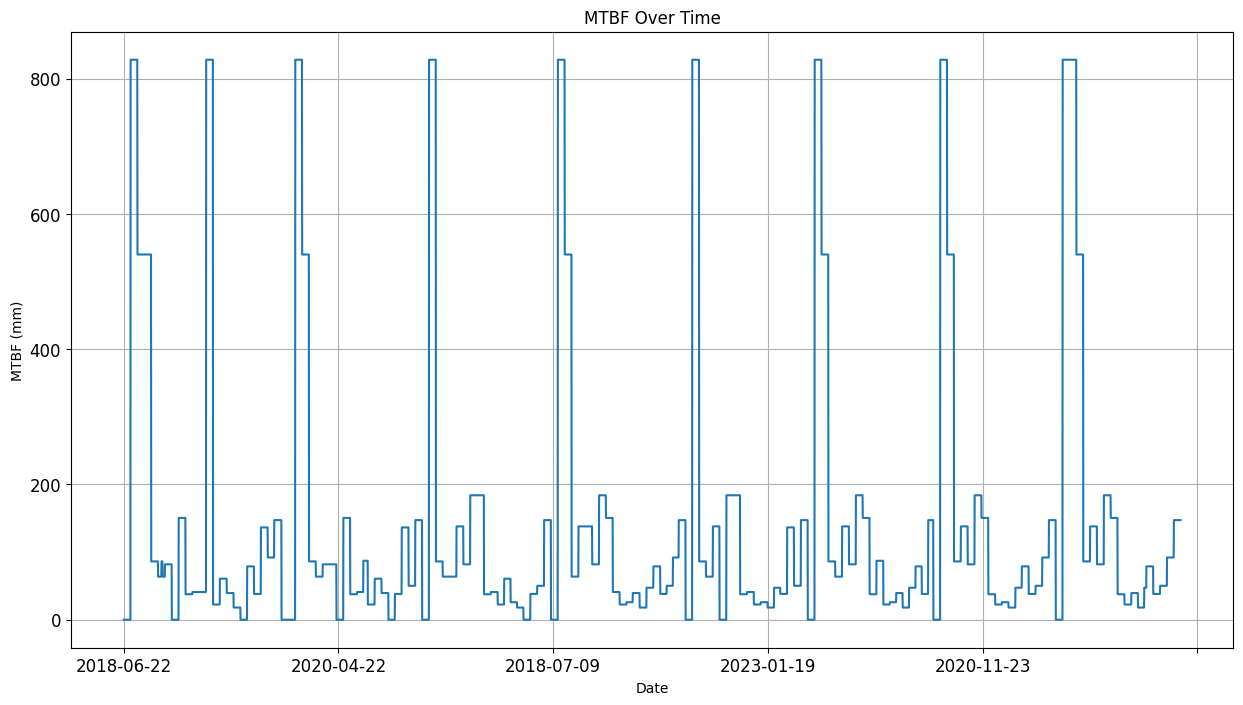

In [ ]:
#plot the time series data
df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['MTBF'].plot(figsize=(15, 8), title='MTBF Over Time', fontsize=12)
plt.ylabel('MTBF (mm)')
plt.grid(True)

In [ ]:
len(df)

4923

In [ ]:
test_size = 3938
test_ind = len(df) - test_size

In [ ]:
train = df.iloc[:test_ind]
test = df.iloc[test_ind:]

In [ ]:
#Feature scalling
from sklearn.preprocessing import MinMaxScaler
numerical_cols = ['MTBF']
scaler = MinMaxScaler()
scaler.fit(train[numerical_cols])

MinMaxScaler()

In [ ]:
# Apply the scaler only to the specified numerical columns
scaled_train = scaler.transform(train[numerical_cols])
scaled_test = scaler.transform(test[numerical_cols])

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
length = 12

# Scale the training data and assign it to scaled_train
scaled_train = scaler.transform(train[numerical_cols])

generator = TimeseriesGenerator(scaled_train,scaled_train,length=length,batch_size=1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,GRU

In [ ]:
n_features = 1
model = Sequential()
model.add(LSTM(100,activation='relu',input_shape=(length,n_features)))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=2)


In [ ]:
validation_generator = TimeseriesGenerator(scaled_train,scaled_train,length=length,batch_size=1)

In [ ]:
model.fit(generator,epochs=20,validation_data=validation_generator,callbacks=[early_stop])

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0304 - val_loss: 0.0141
Epoch 2/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0087 - val_loss: 0.0072
Epoch 3/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0079 - val_loss: 0.0062
Epoch 4/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0078 - val_loss: 0.0060
Epoch 5/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0043 - val_loss: 0.0056
Epoch 6/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0072 - val_loss: 0.0053
Epoch 7/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0044 - val_loss: 0.0053
Epoch 8/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0041 - val_loss: 0.0053
Epoch 9/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0043 - val_loss: 0.0054
Epoch 10/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 11/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0044 - val_loss: 0.0052
Epoch 12/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 26

<Axes: >

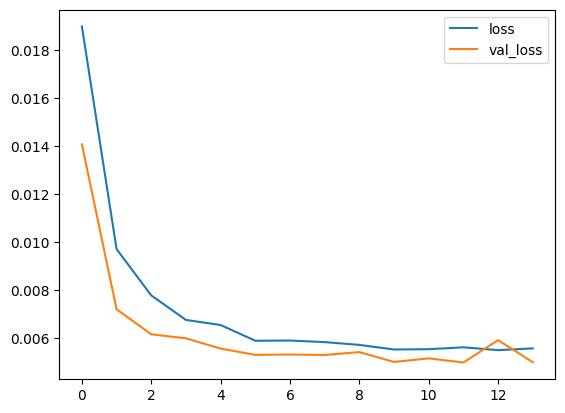

In [ ]:
losses = pd.DataFrame(model.history.history)
losses.plot()

In [ ]:
test_predictions = []
first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1,length,n_features))

for i in range(len(test)):
    #get prediction 1 time stamp ahead
    current_pred = model.predict(current_batch)[0]
    #store prediction
    test_predictions.append(current_pred)
    #update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

In [19]:
true_prediction = scaler.inverse_transform(test_predictions)

In [20]:
test['Predictions'] = true_prediction

<ipython-input-20-661b3dfb2b25>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_prediction


<ipython-input-36-6ec82f87b957>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['LSTM Predictions'] = true_prediction


<Axes: title={'center': 'Actual vs LSTM-Predicted MTBF'}, xlabel='Date'>

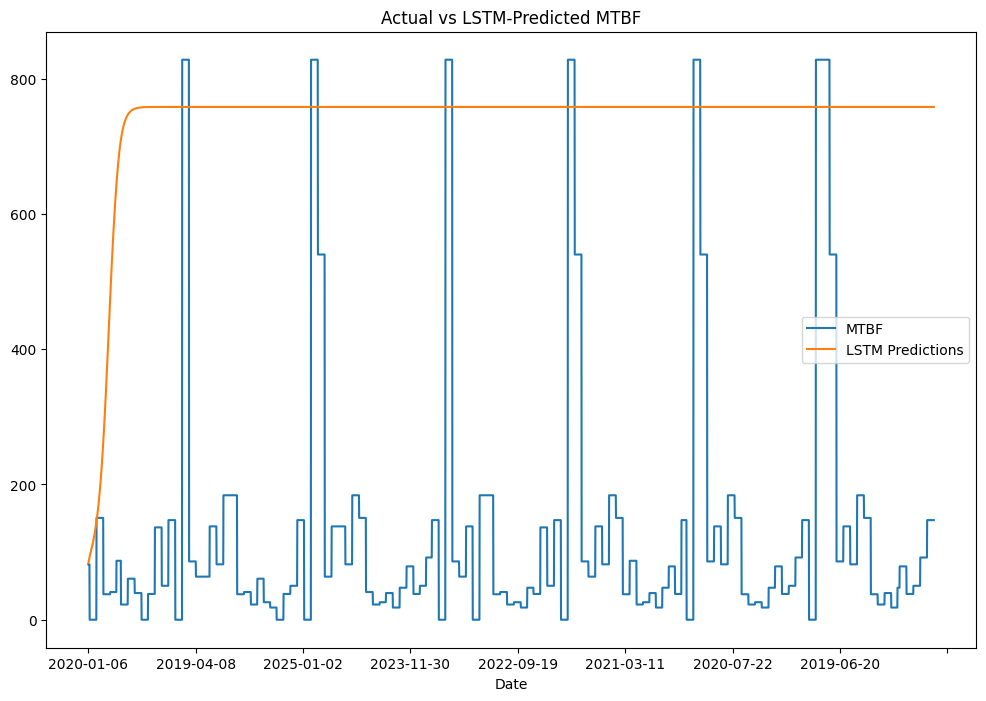

In [36]:
# Inverse transform the test predictions
true_prediction = scaler.inverse_transform(test_predictions)

# Assign the inverse transformed predictions to a new column in the test DataFrame
# Using 'LSTM Predictions' to match the plot title
test['LSTM Predictions'] = true_prediction

# Plot the actual MTBF and the LSTM predictions
test[['MTBF', 'LSTM Predictions']].plot(figsize=(12,8), title='Actual vs LSTM-Predicted MTBF')

In [38]:
# Display the first 5 rows of the test DataFrame showing actual and predicted values
print("Actual vs LSTM Predicted value:")
print(test[['MTBF', 'LSTM Predictions']])

Actual vs LSTM Predicted value:
                  MTBF  LSTM Predictions
Date                                    
2020-01-06   81.900000         83.984249
2020-01-06   81.900000         85.595570
2020-01-06   81.900000         87.192800
2020-01-06   81.900000         88.761252
2020-01-06   81.900000         90.286545
...                ...               ...
2025-03-13  147.272727        758.194877
2025-03-13  147.272727        758.194877
2025-03-13  147.272727        758.194877
2025-03-13  147.272727        758.194877
2025-03-13  147.272727        758.194877

[3938 rows x 2 columns]


In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
from math import sqrt
mae = mean_absolute_error(test['MTBF'],test['Predictions'])
mae

619.3509500620838

In [23]:
mse = mean_squared_error(test['MTBF'],test['Predictions'])
mse

418483.7741225049

In [24]:
rmse = sqrt(mse)
rmse

646.9032185130206

In [25]:
from sklearn.metrics import r2_score
r2 = r2_score(test['MTBF'],test['Predictions'])
r2

-9.755638857172157

In [26]:
from sklearn.preprocessing import MinMaxScaler
# Assuming 'WheelDiameter' is the only numerical column you want to scale
# If you have other numerical columns, add them to this list
numerical_cols_full = ['MTBF']

full_scaler = MinMaxScaler()
# Apply the scaler only to the specified numerical column(s) in the full DataFrame
scaled_full_data = full_scaler.fit_transform(df[numerical_cols_full])

In [27]:
length = 12
generator = TimeseriesGenerator(scaled_full_data,scaled_full_data,length=length,batch_size=1)

In [28]:
model = Sequential()
model.add(LSTM(100,activation='relu',input_shape=(length,n_features)))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

model.fit(generator,epochs=6)

Epoch 1/6


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4911/4911 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - loss: 0.0158
Epoch 2/6
4911/4911 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - loss: 0.0047
Epoch 3/6
4911/4911 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 0.0039
Epoch 4/6
4911/4911 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - loss: 0.0043
Epoch 5/6
4911/4911 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - loss: 0.0032
Epoch 6/6
4911/4911 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.0033


In [30]:
forecast = []
#Replace periods with whatever forecast length you want
periods = 12
first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1,length,n_features))

for i in range(periods):
    #get prediction 1 time stamp ahead
    current_pred = model.predict(current_batch)[0]

    forecast.append(current_pred)
    #update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [31]:
forecast = scaler.inverse_transform(forecast)

In [33]:
last_date = df.index[-1]
# Assuming daily frequency
forecast_index = pd.date_range(start=last_date, periods=periods+1, freq='D')[1:]

forecast_df = pd.DataFrame(forecast,index=forecast_index,columns=['Forecast LSTM'])

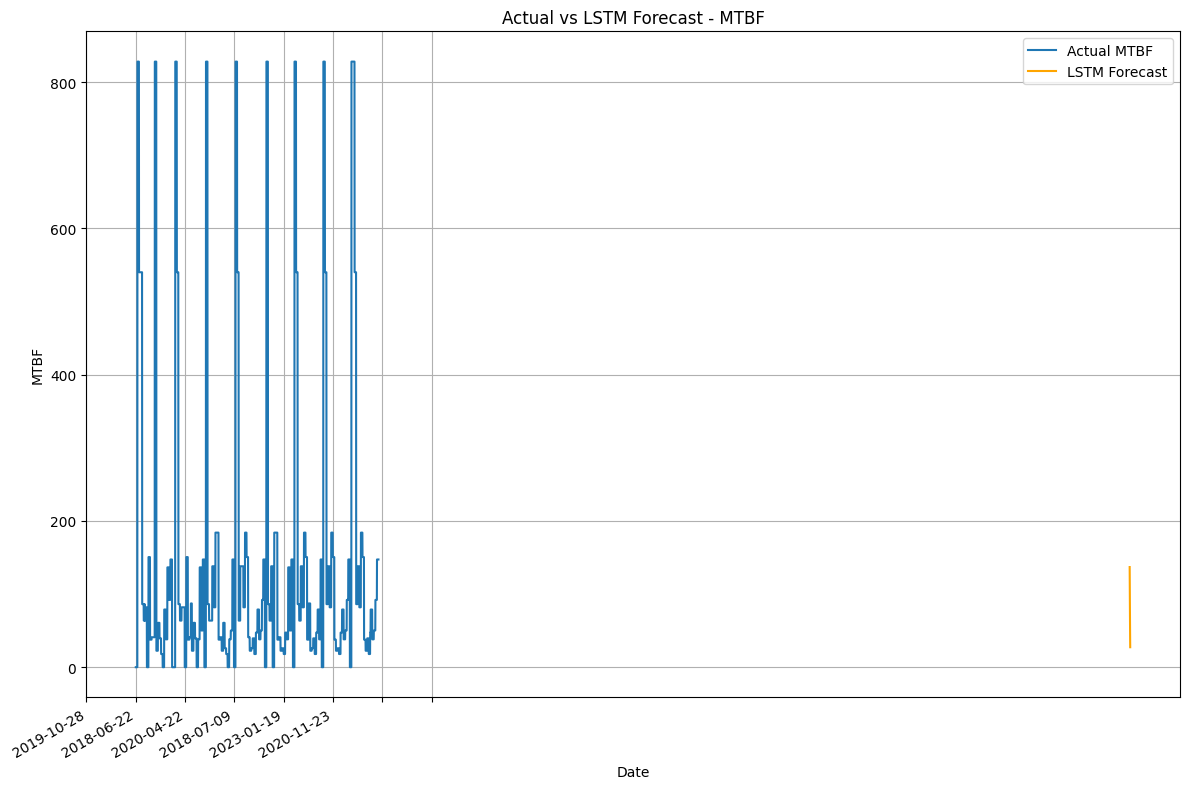

In [34]:
import matplotlib.pyplot as plt

# Plotting actual and GRU forecasted WheelDiameter
ax = df['MTBF'].plot(label='Actual MTBF', figsize=(12, 8))
# Changed 'GRU Forecast' to 'Forecast GRU' to match the DataFrame column name
forecast_df['Forecast LSTM'].plot(ax=ax, label='LSTM Forecast', color='orange')

# Titles and labels
plt.title('Actual vs LSTM Forecast - MTBF')
plt.xlabel('Date')
plt.ylabel('MTBF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()